In [229]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cpu'

## 1. Data (perpating and loading)

In [241]:
weight = 0.7
bias = 0.3

start = 0 
end = 1
step = 0.01
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400],
         [0.0500],
         [0.0600],
         [0.0700],
         [0.0800],
         [0.0900]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280],
         [0.3350],
         [0.3420],
         [0.3490],
         [0.3560],
         [0.3630]]))

In [242]:
len(X),len(y)

(100, 100)

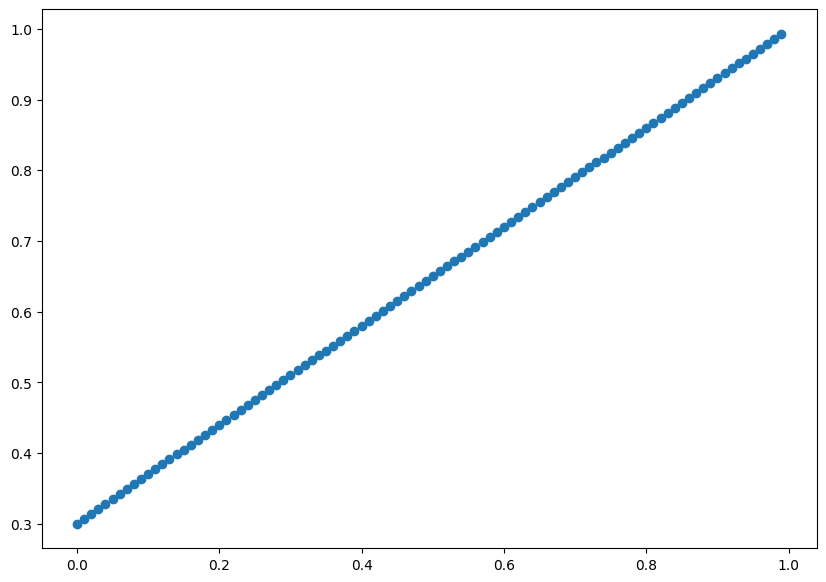

In [243]:
plt.figure(figsize=(10,7))
plt.scatter(X,y)
plt.show()

In [244]:
X_new =X
# X_new+= 0.1*torch.randn_like(X)
y_new =y+ 0.1*torch.randn_like(y)

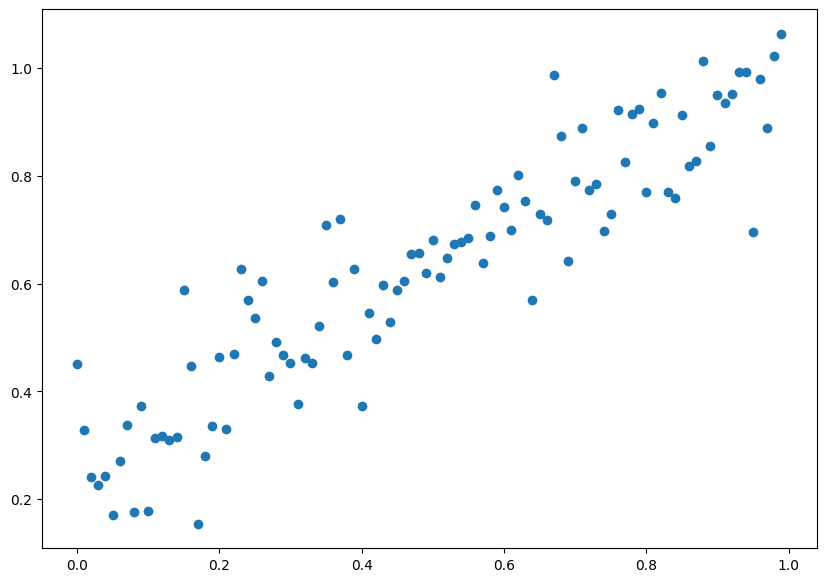

In [245]:
plt.figure(figsize=(10,7))
plt.scatter(X_new,y_new)
plt.show()

In [246]:
# X += 0.1*torch.rand_like(X)
y += 0.1*torch.rand_like(y)

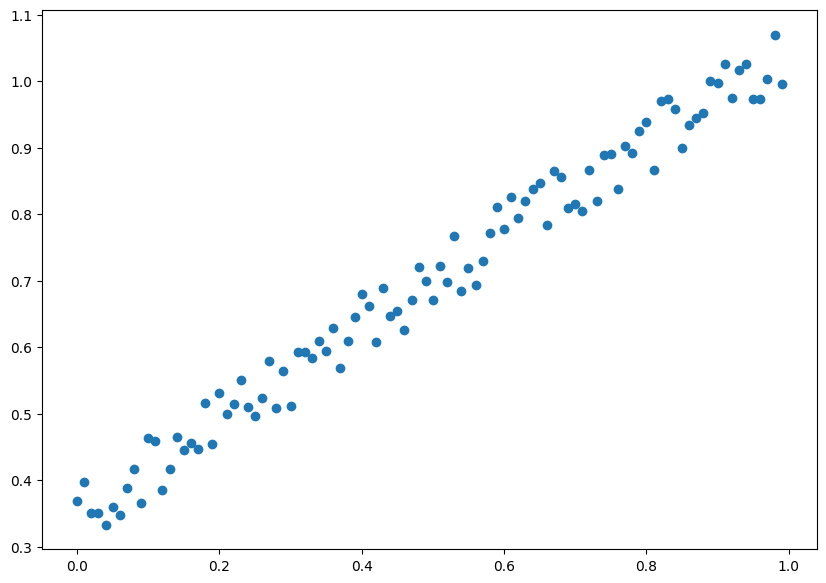

In [247]:
plt.figure(figsize=(10,7))
plt.scatter(X,y)
plt.show()

### Splitting data to train/test

In [248]:
train_split = int(0.8*len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(80, 80, 20, 20)

In [249]:
def plot_prediction(X_train=X_train, 
                    y_train=y_train,
                    X_test=X_test,
                    y_test=y_test,
                    prediction=None):

    plt.figure(figsize=(10,7))
    plt.scatter(X_train,y_train, label="Train data")
    plt.scatter(X_test,y_test, label="Test data")
    if prediction is not None :
        plt.scatter(X_test,prediction, label="Prediction")
    plt.show()

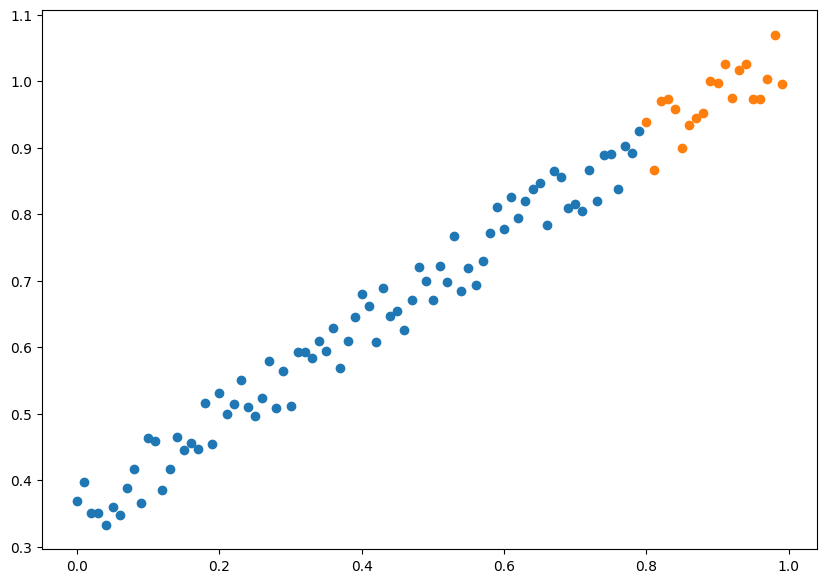

In [250]:
plot_prediction()

## 2. Build model

In [269]:
# Create linear regression model

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                            requires_grad=True, # Default is True
                            dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                            dtype=torch.float))
                            
    # Forward method for computation in the model
    def forward(self, x:torch.Tensor):
        return self.weights* x + self.bias
    

### Checking the content of PyTorch model

In [270]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()

# Check out the parameter
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [271]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Make first prediction

In [272]:
with torch.inference_mode():
    y_pred = model_0(X_test)

#### The same as torch.inference_mode()
# with torch.no_grad():
#     y_pred = model_0(X_test)

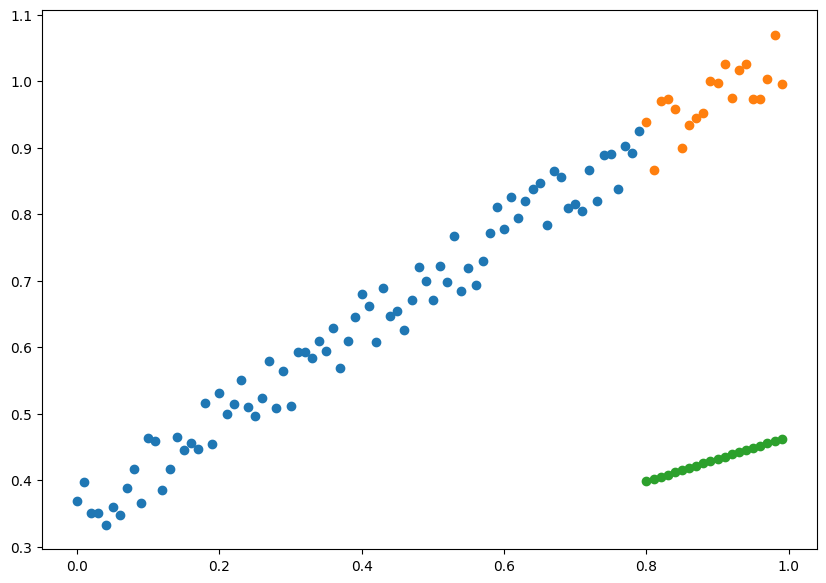

In [273]:
plot_prediction(prediction=y_pred)

## 3. Train model

In [274]:
# Setup a Loss function 
loss_fn = nn.L1Loss()

# Setup an Optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                        lr=0.01)

### Building a training/testing loop

In [275]:
epochs = 250 # epoch is one loop through the data

epoch_count = []
loss_values = []
test_loss_values = []
### Training
for epoch in range(epochs):
    
    # Set model to train for training option(such as Dropout, Gradient ,...)
    model_0.train()

    # 1. Forward pass
    y_pred = model_0(X_train)

    # 2. Calculate the loss
    loss = loss_fn(y_pred,y_train)
    
    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Backpropagation
    loss.backward()

    # 5. Step the optimizer
    optimizer.step() 

   
    # Test model
    model_0.eval()
    with torch.inference_mode():
        # 1. Forward pass 
        test_pred = model_0(X_test)

        # 2. Calculate the loss
        test_loss = loss_fn(test_pred,y_test)

     # Extra term for detail while training
    if epoch%10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f"Epoch:{epoch} | Loss:{loss} | Test Loss:{test_loss}")
    



Epoch:0 | Loss:0.36560165882110596 | Test Loss:0.5312533378601074
Epoch:10 | Loss:0.24999909102916718 | Test Loss:0.39590078592300415
Epoch:20 | Loss:0.1350926011800766 | Test Loss:0.26132968068122864
Epoch:30 | Loss:0.06737037003040314 | Test Loss:0.16001732647418976
Epoch:40 | Loss:0.050916243344545364 | Test Loss:0.1114608496427536
Epoch:50 | Loss:0.04743846505880356 | Test Loss:0.09382008761167526
Epoch:60 | Loss:0.04478500038385391 | Test Loss:0.08348511159420013
Epoch:70 | Loss:0.04238855093717575 | Test Loss:0.07645468413829803
Epoch:80 | Loss:0.04007994011044502 | Test Loss:0.06902041286230087
Epoch:90 | Loss:0.03819466382265091 | Test Loss:0.06375961005687714
Epoch:100 | Loss:0.036456286907196045 | Test Loss:0.06039377301931381
Epoch:110 | Loss:0.03507529944181442 | Test Loss:0.05791730806231499
Epoch:120 | Loss:0.03377198055386543 | Test Loss:0.05441479757428169
Epoch:130 | Loss:0.03265031427145004 | Test Loss:0.05047018080949783
Epoch:140 | Loss:0.03192231059074402 | Test Lo

In [267]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.6675], requires_grad=True),
 Parameter containing:
 tensor([0.3628], requires_grad=True)]

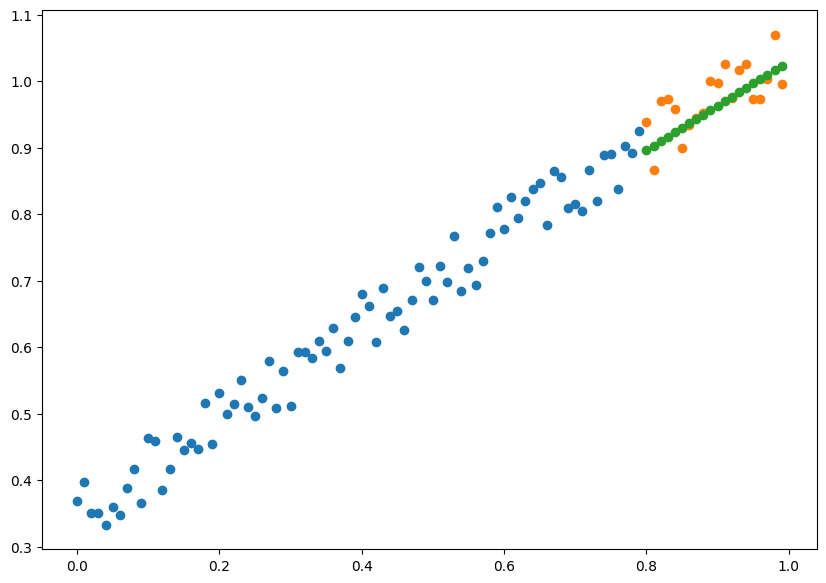

In [268]:
with torch.inference_mode():
    model_0.eval()
    y_pred = model_0(X_test)

plot_prediction(prediction=y_pred)

### Plots train/test loss

In [283]:
# Just for visualize 
loss_values = torch.tensor(loss_values).detach().clone().numpy()

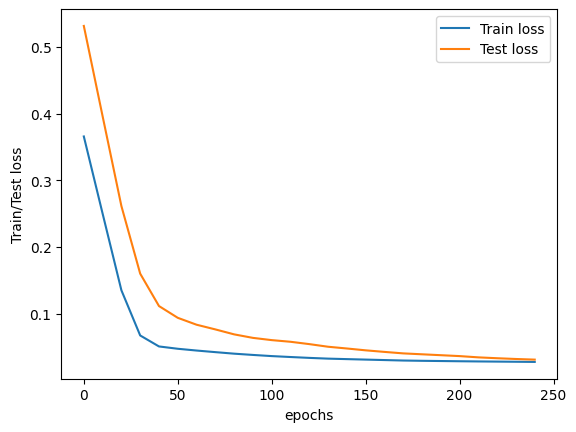

In [284]:
plt.plot(epoch_count,loss_values,label="Train loss")
plt.plot(epoch_count,test_loss_values,label="Test loss")
plt.ylabel("Train/Test loss")
plt.xlabel("epochs")
plt.legend()
plt.show()